<a href="https://colab.research.google.com/github/Jihad-chaalan/AIxMed/blob/main/MLP_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AIxMed26 — Session 2 Assignment
## Neural Networks (MLP) on the Pima Indians Diabetes Dataset

---

### Dataset Description

The **Pima Indians Diabetes Dataset** comes from the National Institute of Diabetes. Each row represents a female patient.

| Feature | Description |
|---------|-------------|
| Pregnancies | Number of times pregnant |
| Glucose | Plasma glucose concentration |
| BloodPressure | Diastolic blood pressure (mm Hg) |
| SkinThickness | Triceps skinfold thickness (mm) |
| Insulin | 2-Hour serum insulin |
| BMI | Body mass index |
| DiabetesPedigreeFunction | Diabetes history score in relatives |
| Age | Age in years |
| **Outcome** | **0 = No Diabetes, 1 = Has Diabetes** |

Follow the same ML cycle from the lecture. Build **three different MLP architectures** in PyTorch, use the validation set to pick the best one, and report test accuracy. Do **not** use the test set until Step 8.

---
## Step 0 — Import Libraries

In [4]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version : {torch.__version__}")
print("Libraries imported successfully!")

PyTorch version : 2.11.0+cu128
Libraries imported successfully!


---
## Step 1 — Define the Problem

In your own words answer the following:
- What is the medical question we are trying to answer?
- What are the inputs (X) and the output (y)?
- What type of ML task is this?
- How does using an MLP differ from using an SVM (Session 1)?

*Write your answer here.*

---
## Step 2 — Load the Data

Load the dataset using the URL below, display its shape and class counts.

```
https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv
```

In [5]:
df = pd.read_csv("https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv")

print(f"Dataset shape: {df.shape}")
print(f"  Rows (patients) : {df.shape[0]}")
print(f"  Columns (feat.) : {df.shape[1] - 1}  + 1 label column")
print()
print("Class counts:")
print(df['Outcome'].value_counts().rename({0: 'No Diabetes (0)', 1: 'Has Diabetes (1)'}))

Dataset shape: (768, 9)
  Rows (patients) : 768
  Columns (feat.) : 8  + 1 label column

Class counts:
Outcome
No Diabetes (0)     500
Has Diabetes (1)    268
Name: count, dtype: int64


---
## Step 3 — Explore the Data

### 3.1 Show the DataFrame

In [6]:
df.head(8)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0


### 3.2 Compare Feature Values: No Diabetes vs Has Diabetes

Plot histograms for all 8 features separated by class.

**Hint:** Use `plt.subplot` in a loop like in the lecture.

In [7]:
feature_columns = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness',
                   'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
label_column = 'Outcome'

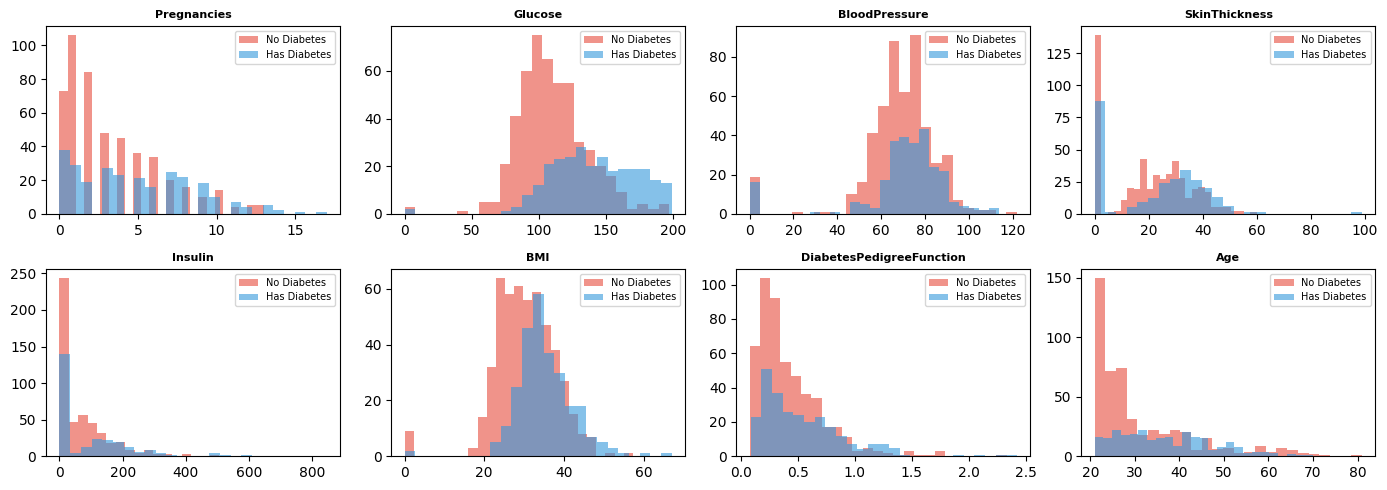

In [8]:
plt.figure(figsize=(14, 5))
for i, feat in enumerate(feature_columns):
    plt.subplot(2, 4, i + 1)

    no_diabetes  = df[df['Outcome'] == 0][feat]
    has_diabetes = df[df['Outcome'] == 1][feat]

    plt.hist(no_diabetes,  bins=25, alpha=0.6, color='#e74c3c', label='No Diabetes')
    plt.hist(has_diabetes, bins=25, alpha=0.6, color='#3498db', label='Has Diabetes')
    plt.title(feat, fontweight='bold', fontsize=8)
    plt.legend(fontsize=7)

plt.tight_layout()
plt.show()

### 3.3 Observations

Which features look most different between the two classes? Write 2–3 sentences.

*Write your observations here.*

---
## Step 4 — Preprocess the Data

### 4.1 Separate Features and Label

Create `X` (all 8 feature columns as a NumPy array) and `y` (the `Outcome` column). Print their shapes.

In [9]:
X = df[feature_columns].values
y = df[label_column].values

print(f"X shape: {X.shape}  (samples × features)")
print(f"y shape: {y.shape}  (one label per sample)")

X shape: (768, 8)  (samples × features)
y shape: (768,)  (one label per sample)


### 4.2 Split into Train / Validation / Test

Use a **60 / 20 / 20** split with `random_state=42` and `stratify=y`. Print the size of each split.

In [10]:
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval
)

print(f"Train      : {len(X_train)} samples  (60%)")
print(f"Validation : {len(X_val)} samples  (20%)")
print(f"Test       : {len(X_test)} samples  (20%)")
print(f"Total      : {len(X)} samples")


Train      : 460 samples  (60%)
Validation : 154 samples  (20%)
Test       : 154 samples  (20%)
Total      : 768 samples


### 4.3 Scale the Features

Apply `StandardScaler`. Fit on **train only**, then transform all three splits.

In [11]:
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Scaling done.")
print(f"  Mean of first feature after scaling: {X_train_s[:, 0].mean():.4f}  (should be ~0)")
print(f"  Std  of first feature after scaling: {X_train_s[:, 0].std():.4f}   (should be ~1)")

Scaling done.
  Mean of first feature after scaling: 0.0000  (should be ~0)
  Std  of first feature after scaling: 1.0000   (should be ~1)


### 4.4 Convert to PyTorch Tensors

PyTorch models require tensor inputs. Convert all six arrays (`X_train_s`, `y_train`, etc.) to `torch.float32` tensors.

**Hint:** Use `torch.tensor(..., dtype=torch.float32)`

In [12]:
X_train_t = torch.tensor(X_train_s, dtype=torch.float32)
y_train_t = torch.tensor(y_train,   dtype=torch.float32)

X_val_t   = torch.tensor(X_val_s,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,     dtype=torch.float32)

X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32)
y_test_t  = torch.tensor(y_test,    dtype=torch.float32)

print(f"X_train_t shape : {X_train_t.shape}")
print(f"y_train_t shape : {y_train_t.shape}")
print("Tensors ready!")

X_train_t shape : torch.Size([460, 8])
y_train_t shape : torch.Size([460])
Tensors ready!


---
## Step 5 — Define Three MLP Architectures

Create three PyTorch models by subclassing `nn.Module`. Each class needs:
- An `__init__` method where you define the layers using `nn.Sequential`
- A `forward` method that passes input `x` through `self.net`

Design your three architectures with **different depths and widths**. Suggestions:

| Model | Suggested Architecture |
|-------|------------------------|
| A | Shallow — 1 hidden layer |
| B | Medium — 2 hidden layers |
| C | Deep + Dropout — 3 hidden layers with `nn.Dropout` |

The input size is **8** (one per feature). The output is **1** logit (no sigmoid — the loss handles it).

Use `nn.ReLU()` as your activation function.

**Hint:** See the lecture notebook for reference.

In [17]:
# ── Model A: Shallow (1 hidden layer) ──────────────────────────────────────
class ModelA(nn.Module):
    """Simple baseline — one hidden layer."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 16),    # ✅ CHANGED: 30 → 8
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)


# ── Model B: Medium (2 hidden layers) ──────────────────────────────────────
class ModelB(nn.Module):
    """Two hidden layers — more capacity."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 32),    # ✅ CHANGED: 30 → 8
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)


# ── Model C: Deep (3 hidden layers + Dropout) ──────────────────────────────
class ModelC(nn.Module):
    """Three hidden layers with Dropout to prevent overfitting."""
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 64),    # ✅ CHANGED: 30 → 8
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )
    def forward(self, x):
        return self.net(x)

In [18]:
# Print parameter counts to verify your architectures
for name, cls in [("Model A", ModelA), ("Model B", ModelB), ("Model C", ModelC)]:
    m = cls()
    n = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f"{name}  —  trainable parameters: {n:,}")

Model A  —  trainable parameters: 161
Model B  —  trainable parameters: 833
Model C  —  trainable parameters: 3,201


---
## Step 6 — Train All Three Models

### 6.1 Write the Training Function

Complete the `train_model` function. Each epoch should:
1. Set the model to **training mode** (`model.train()`)
2. Zero the gradients (`optimizer.zero_grad()`)
3. Forward pass — get logits from the model
4. Compute the loss using `nn.BCEWithLogitsLoss`
5. Backward pass (`loss.backward()`)
6. Update weights (`optimizer.step()`)
7. Set the model to **eval mode** (`model.eval()`) and compute validation accuracy with `torch.no_grad()`

Use **`torch.optim.Adam`** as the optimizer.

In [19]:
def train_model(model, epochs=150, lr=1e-3):
    """Train a model and return per-epoch train loss and val accuracy."""
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses, val_accs = [], []

    for epoch in range(epochs):
        # ── Training ──────────────────────────────────────
        model.train()                          # training mode (enables Dropout)
        logits = model(X_train_t).squeeze()    # forward pass → raw scores
        loss   = criterion(logits, y_train_t)  # compute loss
        loss.backward()                        # backprop → compute gradients
        optimizer.step()                       # update weights

        # ── Validation ────────────────────────────────────
        model.eval()                           # eval mode (disables Dropout)
        with torch.no_grad():
            val_logits = model(X_val_t).squeeze()
            val_preds  = (torch.sigmoid(val_logits) >= 0.5).float()
            val_acc    = (val_preds == y_val_t).float().mean().item()

        train_losses.append(loss.item())
        val_accs.append(val_acc)

    best_val_acc = max(val_accs)
    return train_losses, val_accs, best_val_acc


print("Training function defined.")

Training function defined.


### 6.2 Train Each Model

Instantiate and train all three models. Print the best validation accuracy for each.

In [20]:
EPOCHS = 150

torch.manual_seed(42)
model_a = ModelA()
loss_a, acc_a, best_a = train_model(model_a, epochs=EPOCHS)
print(f"Model A — Best Val Accuracy: {best_a*100:.2f}%")

torch.manual_seed(42)
model_b = ModelB()
loss_b, acc_b, best_b = train_model(model_b, epochs=EPOCHS)
print(f"Model B — Best Val Accuracy: {best_b*100:.2f}%")

torch.manual_seed(42)
model_c = ModelC()
loss_c, acc_c, best_c = train_model(model_c, epochs=EPOCHS)
print(f"Model C — Best Val Accuracy: {best_c*100:.2f}%")

Model A — Best Val Accuracy: 72.73%
Model B — Best Val Accuracy: 81.17%
Model C — Best Val Accuracy: 80.52%


### 6.3 Plot Training Curves

Plot **training loss** and **validation accuracy** over epochs for all three models on two side-by-side subplots.

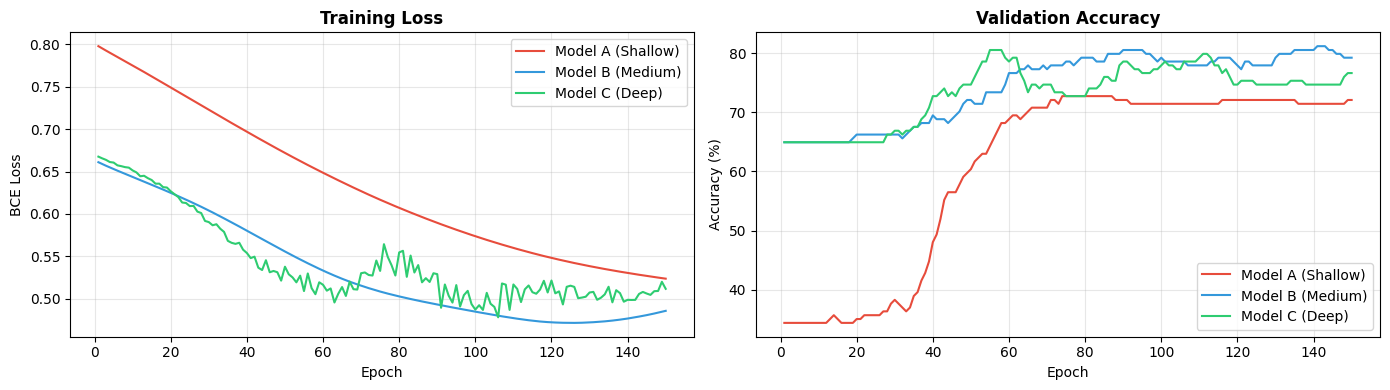

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

epochs_range = range(1, EPOCHS + 1)

# Training loss
axes[0].plot(epochs_range, loss_a, label='Model A (Shallow)', color='#e74c3c')
axes[0].plot(epochs_range, loss_b, label='Model B (Medium)',  color='#3498db')
axes[0].plot(epochs_range, loss_c, label='Model C (Deep)',    color='#2ecc71')
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('BCE Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Validation accuracy
axes[1].plot(epochs_range, [a*100 for a in acc_a], label='Model A (Shallow)', color='#e74c3c')
axes[1].plot(epochs_range, [a*100 for a in acc_b], label='Model B (Medium)',  color='#3498db')
axes[1].plot(epochs_range, [a*100 for a in acc_c], label='Model C (Deep)',    color='#2ecc71')
axes[1].set_title('Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


---
## Step 7 — Select the Best Model

Compare the best validation accuracy of all three models and select the winner.

Print a summary table and identify the best model.

In [22]:
candidates = {
    "Model A (Shallow)       30→32→1"             : (model_a, best_a),
    "Model B (Medium)        30→64→32→1"          : (model_b, best_b),
    "Model C (Deep+Dropout)  30→128→64→32→1"     : (model_c, best_c),
}

print(f"{'Architecture':<45}  {'Val Accuracy':>14}")
print("-" * 62)
for name, (model, acc) in candidates.items():
    print(f"  {name:<43}  {acc*100:>12.2f}%")

best_name  = max(candidates, key=lambda k: candidates[k][1])
best_model = candidates[best_name][0]
best_acc   = candidates[best_name][1]

print()
print(f"Winner → {best_name.strip()}  (Val Acc = {best_acc*100:.2f}%)")


Architecture                                     Val Accuracy
--------------------------------------------------------------
  Model A (Shallow)       30→32→1                     72.73%
  Model B (Medium)        30→64→32→1                  81.17%
  Model C (Deep+Dropout)  30→128→64→32→1              80.52%

Winner → Model B (Medium)        30→64→32→1  (Val Acc = 81.17%)


---
## Step 7b — Reflect on Validation Results

- Which architecture gave the best validation accuracy?
- Did more layers always help? What might explain the results?
- Why do we not use the test set to make this decision?

- Model B (Medium) — with architecture 30 → 64 → 32 → 1 — achieved the highest
validation accuracy at 81.17%.
- No, more layers did NOT always help. Model A (Shallow, 72.73%): This model is too simple (underfitting). Model C (Deep+Dropout, 80.52%): This model is too complex for the amount of data. Model B (Medium, 81.17% — The Winner): This is the Goldilocks ("just right") architecture. With 2 hidden layers (64 → 32), it has enough capacity to learn the intricate patterns in the tumor data, but not so many knobs that it gets lost or heavily choked by Dropout. It hits the perfect trade-off between capacity and generalization.     
- We use the Validation Set to pick the winner, and we lock the Test Set in a vault until the very end, for one critical reason: Data Leakage and Overfitting to the Test Set.

---
## Step 8 — Evaluate on the Test Set (Once!)

Use the best model to predict on the test set.
- Set the model to eval mode
- Use `torch.no_grad()` and `torch.sigmoid` to get predicted probabilities
- Threshold at 0.5 to get class predictions
- Print the final test accuracy and plot the confusion matrix

In [23]:
best_model.eval()
with torch.no_grad():
    test_logits = best_model(X_test_t).squeeze()
    test_preds  = (torch.sigmoid(test_logits) >= 0.5).float().numpy()

test_acc = accuracy_score(y_test, test_preds)

print("=" * 40)
print("  FINAL TEST ACCURACY")
print("=" * 40)
print(f"  {test_acc*100:.2f}%")
print("=" * 40)


  FINAL TEST ACCURACY
  74.03%


---
*AIxMed26 — Session 2 Assignment*